<div style="width: 100%; clear: both;">

<div style="float: left; width: 50%;">

<img src="http://www.uoc.edu/portal/_resources/common/imatges/marca_UOC/UOC_Masterbrand.jpg" align="left">

</div>

<div style="float: right; width: 50%;">

<p style="margin: 0; padding-top: 22px; text-align:right;">M2.991 · Aprenentatge automàtic · PAC2</p>

<p style="margin: 0; text-align:right;">2024-1 · Màster universitari en Ciència de dades (Data science)</p>

<p style="margin: 0; text-align:right; padding-button: 100px;">Estudis d'Informàtica, Multimèdia i Telecomunicació</p>

</div>

</div>

<div style="width:100%;">&nbsp;</div>

# PAC 2: Aprenentatge no supervisat

En aquesta pràctica, explorarem l'ús de models de llenguatge grans (LLMs) per generar embeddings, aplicarem tècniques de reducció de dimensionalitat i utilitzarem diversos algorismes de clustering per analitzar el feedback de clients sobre l'empresa UPS obtingut de Yelp. En acabar, realitzarem una anàlisi detallada dels resultats obtinguts.

**Important:** cadascun dels exercicis pot suposar diversos minuts d'execució, per la qual cosa el lliurament s'ha de fer en format notebook i en format html, on es vegi el codi, els resultats i comentaris de cada exercici. Es pot exportar el notebook a html des del menú File $\to$ Download as $\to$ HTML.

**Important:** hi ha un tipus de cel·la especial per contenir text. Aquest tipus de cel·la us serà molt útil per respondre les diferents preguntes teòriques plantejades al llarg d'aquesta PAC. Per canviar el tipus de cel·la a aquest tipus, trieu al menú: Cell $\to$ Cell Type $\to$ Markdown.

**Important:** no oblideu posar el vostre nom i cognoms a la següent cel·la.

<div class="alert alert-block alert-info">
<strong>Nom i cognoms:</strong>
</div>

Albert Lozano Valverde

Per a la realització de la pràctica necessitarem importar els següents mòduls:

In [1]:
import json
from typing import List
import pandas as pd

from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
from sentence_transformers import SentenceTransformer
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist
from sklearn import datasets
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, HDBSCAN, MeanShift, estimate_bandwidth
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import tqdm
import umap

seed = 42

C:\Users\alber\anaconda3\envs\environment_uoc20241pec2\Lib\site-packages\sentence_transformers\cross_encoder\CrossEncoder.py:13: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange


## Càrrega del conjunt de dades i preprocessament (1,5 punts)

S'utilitzarà un dataset de comentaris de clients sobre l'empresa UPS recopilats de [Yelp](https://www.yelp.com/dataset), contingut en l'arxiu reviews_ups.txt, on cada línia és una review. Recordeu que pot haver-hi reviews sense contingut, les quals hauran de ser eliminades durant el preprocessament.

<div class="alert alert-block alert-info">
<strong>Implementació:</strong> carrega les opinions de l'arxiu en una llista i elimina aquelles opinions que estiguin literalment buides.
</div>

In [2]:

data = []
with open('reviews_stars_ups.json',encoding="utf-8") as f:
    for line in f:
        if len((line))>=1 and line!="\n":
            try:
                temp=json.loads(line)
                if len(temp["text"])>0:
                    data.append(temp)
                else:
                    print(line +" el text es buit")
            except:
                print(line +" li falten dades")
        

{"text":"","stars":}
 li falten dades
{"text":"","stars":3}
 el text es buit


Avui en dia, l'anàlisi de text en llenguatge natural ha estat revolucionat pels Models de Llenguatge Grans (LLMs), els quals han reemplaçat les tècniques clàssiques com TF-IDF i Bag of Words per a la representació de text. Aquestes tècniques clàssiques, tot i que útils, eren limitades en crear representacions disperses i poc contextuals dels textos. En canvi, els LLMs permeten generar representacions denses o embeddings, que capturen de manera molt més efectiva el significat semàntic de les paraules i les relacions entre elles.

Per comprendre com funcionen els models de llenguatge es recomana el següent vídeo que, al minut 12, explica visualment la part d'embeddings (representació vectorial de paraules o frases) que utilitzarem en la PAC: https://www.youtube.com/watch?v=wjZofJX0v4M

En aquesta pràctica, crearem una representació densa (embedding) de les reviews utilitzant MiniLM, un model lleuger que ofereix una excel·lent capacitat per generar embeddings de text mantenint un equilibri entre rendiment i eficiència computacional. MiniLM està basat en l'arquitectura Transformer, similar a altres models més grans com BERT, però optimitzat per ser més petit i ràpid, cosa que el fa ideal per a tasques com la nostra. En concret, utilitzarem la versió "all-MiniLM-L6-v2", que pots descarregar comprimida en un fitxer zip des del següent enllaç: https://public.ukp.informatik.tu-darmstadt.de/reimers/sentence-transformers/v0.2/all-MiniLM-L6-v2.zip

Un cop descarregat l'arxiu, has de descomprimir-lo i col·locar el directori extret en el mateix directori on es troba aquest notebook, per facilitar-ne la càrrega.

Per carregar el model, utilitzarem la biblioteca sentence-transformers, que és una eina que facilita l'ús de models preentrenats per a la generació d'embeddings de text. Aquesta biblioteca està construïda sobre models com BERT, MiniLM, i altres, i ens permet, amb unes poques línies de codi, transformar frases i textos en representacions vectorials d'alta qualitat. Aquí pots trobar més documentació sobre sentence-transformers i el model en concret de MiniLM: https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2

En tenir el model descarregat en local només cal indicar el nom del directori descomprimit on es troba el model (que coincideix amb el nom del model).

<div class="alert alert-block alert-info">
<strong>Implementació:</strong> carrega el model de MiniLM i crea l'embedding per a la frase "Estic resolent la PAC 2"
</div>

In [3]:
from sentence_transformers import SentenceTransformer
sentences = ["Estic resolent la PAC 2"]

model = SentenceTransformer('all-MiniLM-L6-v2')
embedding = model.encode(sentences,batch_size=256)


Per crear els embeddings de cadascuna de les frases del dataset, hem de tenir en compte que aquest procés pot ser una mica més lent que algunes altres operacions, ja que implica transformar cada frase en una representació densa a través d'un model de llenguatge. Depenent de la mida del dataset i de la capacitat de la màquina, el temps requerit podria ser d'uns 5 minuts en una màquina estàndard. Tot i això, podem aplicar certes optimitzacions per accelerar aquest procés.

Una manera eficient de fer-ho és processar les frases en lots (batches) en lloc de processar-les una per una. La biblioteca sentence-transformers ens permet passar directament la llista completa de frases i dividir-les en lots més petits, fent que el càlcul dels embeddings sigui més ràpid aprofitant la capacitat de paral·lelització de la màquina. Per a això, podem utilitzar el paràmetre batch_size en el mètode `encode()`. Per exemple, si configurem `batch_size=256`, indicarem al model que processi 256 reviews al mateix temps, cosa que accelera el processament considerablement. Si el procés és molt lent, pots reduir aquest nombre perquè s'adapti a les característiques de la teva màquina.

A més, per poder fer un seguiment del progrés del càlcul, podem habilitar una barra de progrés amb el paràmetre `show_progress_bar=True`. Això ens permetrà tenir una visió clara de quant falta per completar el processament, cosa que és especialment útil quan treballem amb datasets grans.

<div class="alert alert-block alert-info">
<strong>Implementació:</strong> calcula l'embedding de totes les reviews (no buides)
</div>

In [4]:
%%time
sentence = [item["text"] for item in data]
embeddings = model.encode(sentence)

CPU times: total: 6min 43s
Wall time: 51.3 s


In [5]:
%%time
sentence = [item["text"] for item in data]
embeddings = model.encode(sentence,batch_size=256)

CPU times: total: 6min 57s
Wall time: 53.1 s


In [6]:
ratings = [item["stars"] for item in data]

<div class="alert alert-block alert-info">
<strong>Anàlisi:</strong> Quantes dimensions té l'embedding generat per MiniLM?
</div>

In [7]:
embeddings.shape

(4485, 384)

## Reducció de dimensionalitat (2,5 punts)

L'embedding generat pel model té una alta dimensionalitat. Tot i que aquesta representació és ideal per capturar relacions semàntiques complexes entre frases, és difícil d'interpretar i visualitzar directament a causa de la gran quantitat de dimensions.

Per poder visualitzar els embeddings i entendre millor com es agrupen les reviews similars, necessitem reduir la dimensionalitat de l'espai a una cosa més manejable, com ara 2 dimensions. En fer-ho, podem representar gràficament les frases en un pla, cosa que ens permetrà identificar patrons, clusters de frases similars i relacions entre diferents opinions.

Pel que fa a la visualització, atès que tenim milers de punts (un per cada embedding generat), és important assegurar-nos que el gràfic no es torni confús o massa saturat. Per a això, utilitzarem un gràfic `scatter` de Matplotlib i aprofitarem el paràmetre `alpha=0.1`, que ajusta la transparència dels punts en el gràfic. Això ens permetrà visualitzar clarament les àrees més denses, ja que, on hi hagi una major concentració de punts, aquests se superposaran i es veuran més foscos, facilitant la identificació de zones amb alta densitat d'opinions similars.

### PCA (Principal Component Analysis)
PCA troba les direccions de major variància en les dades i projecta els punts cap a aquestes direccions. És ràpida i eficient, però cal tenir en compte que en alguns casos pot no capturar bé les relacions no lineals presents en els embeddings.

<div class="alert alert-block alert-info">
<strong>Implementació:</strong> redueix a 2 dimensions cadascuna de les reviews i visualitza el resultat on el color de cada punt es correspongui amb les estrelles d'aquesta review. Afegeix una llegenda per poder interpretar els colors.
</div>

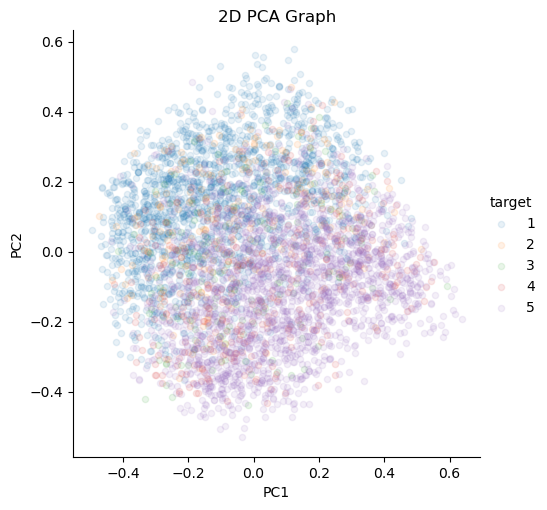

In [8]:
import seaborn as sns
from sklearn.decomposition import PCA
X = embeddings
y=ratings
pca = PCA(n_components=2)
pca_features = pca.fit_transform(X)
pca_df = pd.DataFrame(
    data=pca_features, 
    columns=['PC1', 'PC2'])
pca_df['target'] = y
sns.lmplot(
    x='PC1', 
    y='PC2', 
    data=pca_df, 
    hue='target', 
    fit_reg=False, 
    legend=True,
    scatter_kws={'alpha': 0.1,"s": 20}
    )

plt.title('2D PCA Graph')
plt.show()

### t-SNE (t-distributed Stochastic Neighbor Embedding)
t-SNE és una tècnica per reduir la dimensionalitat preservant les relacions locals (és a dir, manté els punts similars a prop els uns dels altres). Tot i que és més lenta que PCA, t-SNE no projecta linealment.

<div class="alert alert-block alert-info">
<strong>Implementació:</strong> redueix a 2 dimensions cadascuna de les reviews i visualitza el resultat on el color de cada punt es correspongui amb les estrelles d'aquesta review. Afegeix una llegenda per poder interpretar els colors.
</div>

In [9]:
from sklearn.manifold import TSNE
X = embeddings
y=ratings
tsne = TSNE(n_components=2 )
tsne_features = tsne.fit_transform(X)


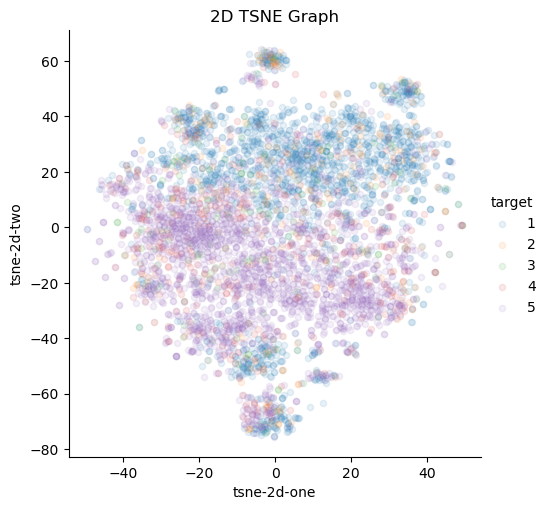

In [10]:
tsne_df = pd.DataFrame(
    data=tsne_features, 
    columns=['tsne-2d-one', 'tsne-2d-two'])
tsne_df['target'] = y
sns.lmplot(
    x='tsne-2d-one', 
    y='tsne-2d-two', 
    data=tsne_df, 
    hue='target', 
    fit_reg=False, 
    legend=True,
    scatter_kws={'alpha': 0.1,"s": 20}
    )

plt.title('2D TSNE Graph')
plt.show()

### UMAP (Uniform Manifold Approximation and Projection)
UMAP és una alternativa relativament nova que, igual que t-SNE, intenta mantenir les relacions locals, però sol ser més ràpida i permet una major flexibilitat per ajustar la precisió dels resultats.

<div class="alert alert-block alert-info">
<strong>Implementació:</strong> redueix a 2 dimensions cadascuna de les reviews i visualitza el resultat on el color de cada punt es correspongui amb les estrelles d'aquesta review. Afegeix una llegenda per poder interpretar els colors.
</div>

In [11]:
from sklearn.preprocessing import StandardScaler
import umap
X = embeddings
y=ratings
X = StandardScaler().fit_transform(X)
reducer = umap.UMAP()
umap_features = reducer.fit_transform(X) 

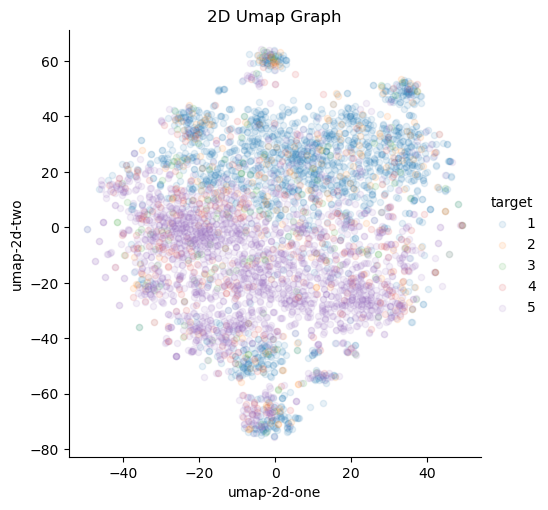

In [12]:
umap_df = pd.DataFrame(
    data=tsne_features, 
    columns=['umap-2d-one', 'umap-2d-two'])
umap_df['target'] = y
sns.lmplot(
    x='umap-2d-one', 
    y='umap-2d-two', 
    data=umap_df, 
    hue='target', 
    fit_reg=False, 
    legend=True,
    scatter_kws={'alpha': 0.1,"s": 20}
    )

plt.title('2D Umap Graph')
plt.show()

In [13]:
df=pd.DataFrame(data)
df.groupby("stars").count()    
    

,text
stars,
1,1687
2,228
3,156
4,329
5,2085


<div class="alert alert-block alert-info">
<strong>Anàlisi:</strong> Què has observat després de la seva aplicació? Tot i no haver utilitzat la informació de les estrelles en realitzar els embeddings, sembla que existeix una relació entre la disposició dels embeddings i el nombre d'estrelles?
</div>

Utilitzant PCA Sembla que hi ha un gradient, on a PC2 més gran i PC1 més petit ves baix és la puntuació i si anem cap a l'altre sentit a les dues variables tenim una puntuació més baixa, però els grups no estan separats simplement és més comú unes puntuacions o altres seguint el gradient, però trobem totes les puntuacions a tots llocs.

A TSNE sembla que la variable 1 no afecta massa a la distribució i la variable 2 entre 60,20 tenim més 1 i entre 10,-40 

Tenim més 5. Però tenim clústers on estan tots barrejats com per exemple per les coordenades {-20,60} o {-10,-70}

UMAP es comporta molt similar a TSNE on la primera variable sembla que no tingui molta rellevància i la segona si, en aquest cas tenim valors d'1 entre 20,60 de la primera variable i els de 5 20,-40.

També tenim clústers amb barreges, com a {-10,-70} o {-10,60}

En general, sembla que tots els exemples tot i no haver utilitzat la informació de les estrelles sembla que ha pogut separar, però només entre les reviews més extremes, suposo que això és com que en ser opinions més polaritzades utilitzaran un llenguatge més concret que les reviews que estan més al mig, per exemple, dir que el producte és bo o és dolent fa més fàcil identificar en comptes d'un llenguatge més neutral. 

També si mirem el nombre de mostres en cada quantitat de punts veiem que la majoria estan en 1 i 5, en concret son 84% dels vots totals, si tinguéssim una distribució igual en tots esperaríem que dos valors donessin el 40%, ja que cada valor seria un 20%. Per tant, veig norma que només veiem la separació entre aquests dos grups 

<div class="alert alert-block alert-info">
<strong>Anàlisi:</strong> Si haguessis de reduir la dimensionalitat per aplicar posteriorment un model d'aprenentatge supervisat que s'entrenarà una vegada i en producció farà prediccions diàries. Quins avantatges i desavantatges tindria cadascun dels mètodes? Per què?
</div>

Com vam veure a l'altre practica TSNE queda descartada directament, ja que està pensat per visualitzar espais d'altes dimensions, per tant, el seu objectiu no és reduir la dimensionalitat, per tant, el descartem directament. Per tant, compararem UMAP amb PCA.

PCA crea és un vector que és la combinació lineal de les n variables que tenim originalment de manera que tinguem la variància més gran, després la segona component és la combinació lineal que té més variància, el segon component ha de ser linealment independent i agafem el segon que tingui més variància això ho podem iterar n vegades fins a tenir el mateix sistema de referència que originalment, per tant, el que estem fent és generar un altre espai vectorial a partir de les variables que tenim. Això fa que sigui un model determinista, ja que calculem la variància més gran.

PCA funciona molt bé quan les variables no són linealment independents entre elles, però el model és lineal, ja que podem absorbir múltiples variables en 1 a causa de la dependència. 

El problema que t'és que la combinació entre les variables que fa és lineal, per tant, si el patró de dades és no lineal podem perdre informació e inculs afegir soroll amb aquest nou sistema de referències. També això fa que sigui molt eficient, ja que les operacions que fa són senzilles, per tant, amb models lineals amb moltes dades aquesta eina és la ideal. 

UMAP o Uniform Manifold Approximation and Projection, és més complex d'explicar, es basa en teoria de topologia per generar un model robust, UMAP és no lineal, per tant, si les dades tenen una relació no lineal serà un millor model. La seva computació és més costosa que per PCA però no absurdament costosa, ja que està molt optimitzat. Pel funcionament de l'algorisme no és determinista, podent donar diferents ressolats a diferents moments.

En cas d'haver d'escollir una manera de fer-ho crec que la característica més rellevant és si el model és lineal o no, ja que en cas que ho sigui PCA serà millor alternativa. 

En el nostre cas específic podria ser que fos lineal i una expressió més alta en certes variables relacionades amb paraules positives dones una review més alta, però no tinc clar si ho és o no.

Jo crec que pot ser lineal i, per tant, escolliré PCA.

### Validació en 3 dimensions

Després de visualitzar la reducció a dues dimensions, tria el mètode de reducció de dimensionalitat que consideris més adequat. A continuació, valida que les estructures identificades es mantenen en estendre la visualització a tres dimensions. Aquesta validació permet afegir més informació i verificar si els patrons observats persisteixen quan s'incorpora una dimensió addicional, la qual cosa proporciona una visió més completa de l'organització de les dades.

<div class="alert alert-block alert-info">
<strong>Implementació:</strong> crea un nou embedding projectant a 3 dimensions amb el mètode triat i visualitza amb matplotlib mantenint el color com a indicatiu del nombre d'estrelles de cada review.
</div>

In [14]:
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


X = embeddings
ratings
pca = PCA(n_components=3)
pca_features3d = pca.fit_transform(X)
pca_df = pd.DataFrame(
    data=pca_features3d, 
    columns=['PC1', 'PC2','PC3'])
x=pca_df['PC1']
y=pca_df['PC2']
z=pca_df['PC3']
pca_df["ratings"]=y

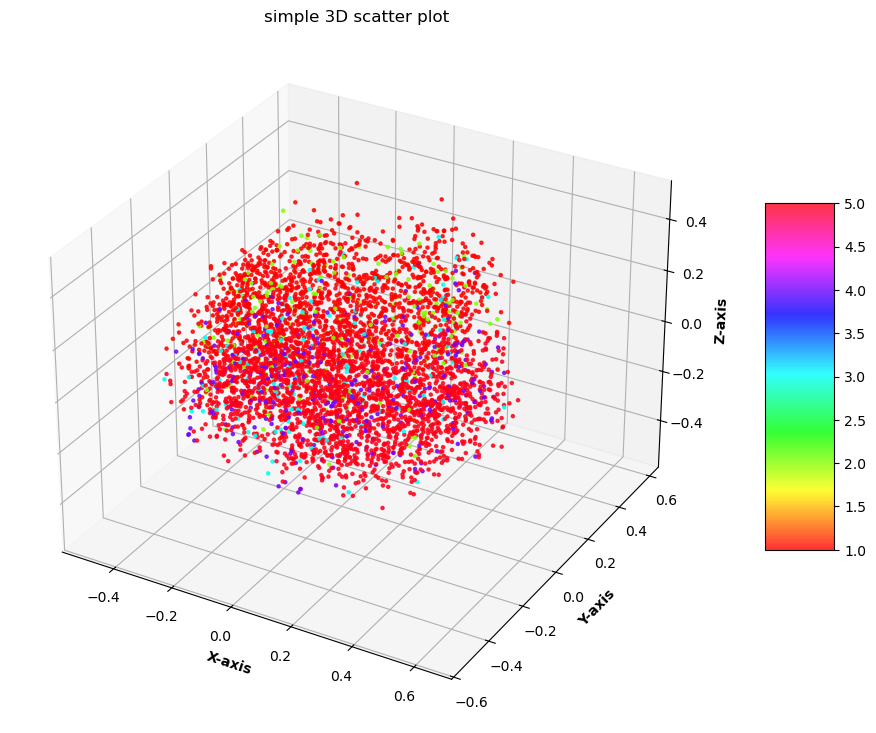

In [15]:

fig = plt.figure(figsize = (16, 9))
ax = plt.axes(projection ="3d")
   
# Add x, y gridlines 
ax.grid(b = True, color ='grey', 
        linestyle ='-.', linewidth = 0.3, 
        alpha = 0.2) 


my_cmap = plt.get_cmap('hsv')
 
# Creating plot
sctt = ax.scatter3D(x, y, z,
                    alpha = 0.8,
                    c = ratings, 
                    cmap = my_cmap, 
                   s= 5)
 
plt.title("simple 3D scatter plot")
ax.set_xlabel('X-axis', fontweight ='bold') 
ax.set_ylabel('Y-axis', fontweight ='bold') 
ax.set_zlabel('Z-axis', fontweight ='bold')
fig.colorbar(sctt, ax = ax, shrink = 0.5, aspect = 5)
 
# show plot
plt.show()


In [17]:
import plotly.express as px
object= StandardScaler()
# Create the 3D scatter plot using plotly.express
fig = px.scatter_3d(pca_df, x="PC1", y='PC2', z='PC3', color='ratings',opacity=0.1,size_max=5)

# Set labels and title
fig.update_layout(scene=dict(
   xaxis_title='X Label',
   yaxis_title='Y Label',
   zaxis_title='Z Label'
))
fig.update_layout(title='3D Scatter Plot')

# Display the plot
fig.update_layout(autosize=True) # remove height=800
fig.show(renderer="browser")
#he utilitzat polty per poder moure la camara al grafic en tres dimensions crea una nova pestaña al navegador en la qual podem moure la visualitzacio

<div class="alert alert-block alert-info">
<strong>Anàlisi:</strong> És coherent aquesta visualització amb el que s'ha observat a la figura 2d?
</div>

Si, s'observa un espai similar al de 2 dimensions on tenim dos grups diferenciats un positiu i un negatiu, on en el qual primer estan principalment les reviews de 5 estrelles i en el segon estan les d'1, la resta estan bastant repartides en tot l'espai, com he dit abans crec que la separació en 2 grups té bastant sentit tant perquè són la majoria de les dades com perquè les opinions més fortes tindran un llenguatge més directe sense donar possibilitat a confusió.

### Dendrograma

A més de la visualització de les dades en 2 dimensions mitjançant mètodes de reducció de dimensionalitat, també podem intentar entendre com es distribueixen els punts en l'espai d'alta dimensionalitat utilitzant una tècnica diferent: el **dendrograma**.

Un dendrograma és una **representació gràfica que mostra l'estructura jeràrquica d'un conjunt de dades**. Aquest tipus de gràfic és especialment útil per entendre les relacions entre punts de dades quan volem agrupar-los de manera jeràrquica. El dendrograma es genera com a part de l'algorisme de clustering jeràrquic, el qual intenta agrupar les dades de manera recursiva, creant una estructura en forma d'arbre on cada fulla representa un punt del dataset i cada bifurcació representa la unió de dos grups.

Com interpretar un dendrograma:

A la part inferior del dendrograma, cada fulla representa una dada individual (en aquest cas, una review).
- A mesura que ens movem cap amunt, els punts que estan més propers entre si es van agrupant, i aquests grups s'uneixen en nivells superiors fins que, eventualment, tots els punts es junten en un únic grup a la part superior.
- Les distàncies verticals indiquen la similitud o dissimilitud entre els grups que s'estan unint. Com més gran és l'altura a la qual s'uneixen dos grups, més gran és la dissimilitud entre ells. Per tant, un dendrograma ens dóna una idea visual de quins punts estan més a prop els uns dels altres i com els clusters més petits es fusionen per formar clusters més grans.
- Utilitzant un dendrograma, podem decidir quants clusters té sentit crear, observant on seria adequat tallar l'arbre. Per exemple, si trobem un punt on els grups comencen a unir-se amb una gran distància, això podria indicar que és un bon lloc per tallar i definir el nombre de clusters.

<div class="alert alert-block alert-info">
<strong>Implementació:</strong> visualitza el dendrograma tenint en compte aquests paràmetres:
<ul>
<li><strong>truncate_mode='level'</strong>: limita la profunditat del dendrograma, mostrant només un nombre determinat de nivells d'unió, cosa que és útil per evitar un gràfic excessivament complex.

<li><strong>p=200</strong>: quants clusters o nivells es mostraran. En aquest cas, es visualitzaran fins a 500 grups, permetent un bon equilibri entre detall i simplicitat.

<li><strong>no_labels=True</strong>: oculta les etiquetes de cada punt per evitar que el gràfic es vegi sobrecarregat i es generi més ràpidament.

<li><strong>method='single'</strong>: és una manera intuïtiva d'agrupar les mostres, ja que defineix la distància entre dos grups com la distància entre els punts més propers de cada grup.
</ul>
</div>

In [18]:
Z = linkage(embeddings, method='single')


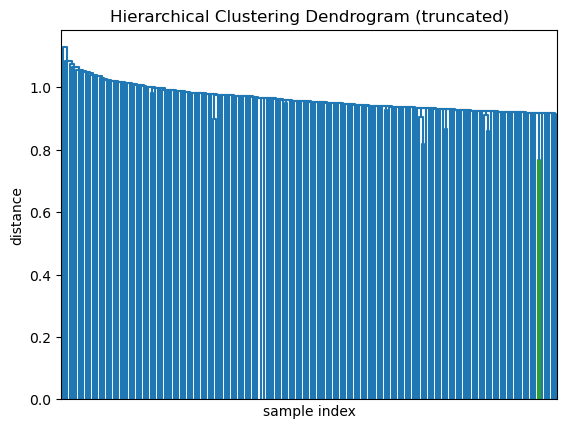

In [19]:
plt.title('Hierarchical Clustering Dendrogram (truncated)')
plt.xlabel('sample index')
plt.ylabel('distance')
dn=dendrogram(
    Z,
    truncate_mode='level',  # show only the last p merged clusters
    p=200,  # show only the last p merged clusters
    no_labels=True,
)

plt.show()

<div class="alert alert-block alert-info">
<strong>Anàlisi:</strong> Què podem observar en el dendrograma? Hi ha alguna cosa semblant a l'observat en les reduccions de dimensionalitat?
</div>

No sembla que trobi cap separació per grups, però si mirem PCA crec que té sentit. El motiu que tinc per pensar això és que si mirem PCA no tenim clústers i la densitat sembla uniforme, per tant, si utilitzem un mètode per separar els grups com single que només es dedica a mirar la distància local no podrà separar  en diferents clústers, ja que la densitat es continua, per tant, localment no es veuen grans canvis.

## Clustering (3 punts)

Després d'haver visualitzat el conjunt de dades i examinat el dendrograma, hem obtingut una visió més profunda sobre l'estructura i les relacions internes del dataset. Aquesta informació ens ajudarà a prendre una decisió informada sobre quina és la millor estratègia de clustering a seguir. Tanmateix, abans de definir la nostra estratègia final, és important explorar com funcionen diferents algorismes de clustering, per comprendre millor els seus avantatges i limitacions.

En aquest context, realitzarem alguns experiments utilitzant diferents algorismes de clustering. Provarem enfocaments com **K-means**, **clustering jeràrquic**, **DBSCAN**, i **Mean-Shift**.

Per a això, comptem amb els següents datasets:

In [29]:
n_samples = 1000
blobs_data, blobs_labels = datasets.make_blobs(n_samples=n_samples, cluster_std=[1.0, 2.5, 0.5], random_state=seed)
moons_data, moons_labels = datasets.make_moons(n_samples=n_samples, noise=0.05, random_state=seed)
circles_data, circles_labels = datasets.make_circles(n_samples=n_samples, factor=0.4, noise=0.05, random_state=seed)

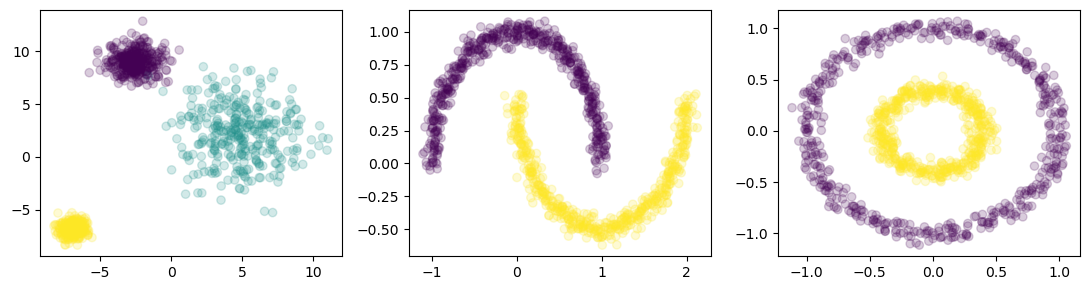

In [30]:
fig, ax = plt.subplots(1, 3, figsize=(11, 3))
ax[0].scatter(blobs_data[:,0], blobs_data[:,1], c=blobs_labels, alpha=.2)
ax[1].scatter(moons_data[:,0], moons_data[:,1], c=moons_labels, alpha=.2)
ax[2].scatter(circles_data[:,0], circles_data[:,1], c=circles_labels, alpha=.2)
plt.tight_layout()

<div class="alert alert-block alert-info">
<strong>Implementació:</strong> aplica K-means als tres datasets anteriors i visualitza el seu resultat.
</div>

C:\Users\alber\anaconda3\envs\environment_uoc20241pec2\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.

C:\Users\alber\anaconda3\envs\environment_uoc20241pec2\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.

C:\Users\alber\anaconda3\envs\environment_uoc20241pec2\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.



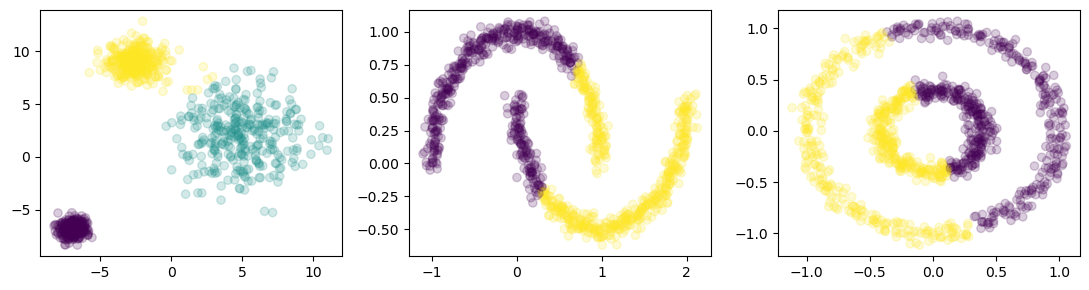

In [31]:
kmeansblb = KMeans(n_clusters=3, random_state=0, n_init="auto").fit(blobs_data)
kmeansmoons = KMeans(n_clusters=2, random_state=0, n_init="auto").fit(moons_data)
kmeanscirc = KMeans(n_clusters=2, random_state=0, n_init="auto").fit(circles_data)
fig, ax = plt.subplots(1, 3, figsize=(11, 3))
ax[0].scatter(blobs_data[:,0], blobs_data[:,1], c=kmeansblb.labels_, alpha=.2)
ax[1].scatter(moons_data[:,0], moons_data[:,1], c=kmeansmoons.labels_, alpha=.2)
ax[2].scatter(circles_data[:,0], circles_data[:,1], c=kmeanscirc.labels_, alpha=.2)
plt.tight_layout()


<div class="alert alert-block alert-info">
<strong>Implementació:</strong> aplica clustering jeràrquic als tres datasets anteriors i visualitza el seu resultat.
</div>

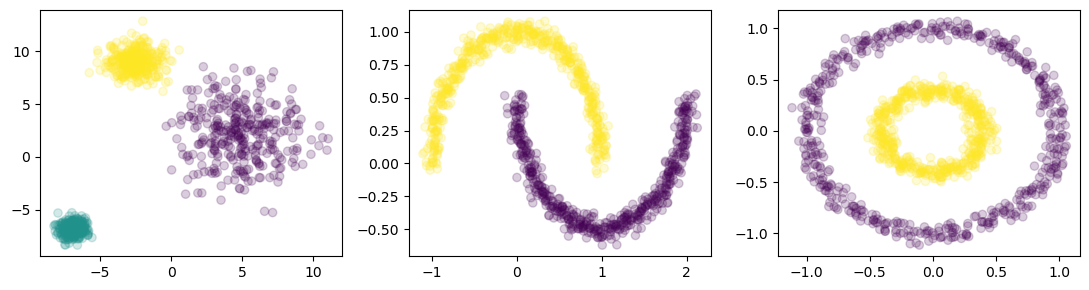

In [32]:

clusteringblb = AgglomerativeClustering(n_clusters=3).fit(blobs_data)
clusteringmoons = AgglomerativeClustering(linkage="single").fit(moons_data)
clusteringcircle = AgglomerativeClustering(linkage="single").fit(circles_data)
fig, ax = plt.subplots(1, 3, figsize=(11, 3))
ax[0].scatter(blobs_data[:,0], blobs_data[:,1], c=clusteringblb.labels_, alpha=.2)
ax[1].scatter(moons_data[:,0], moons_data[:,1], c=clusteringmoons.labels_, alpha=.2)
ax[2].scatter(circles_data[:,0], circles_data[:,1], c=clusteringcircle.labels_, alpha=.2)
plt.tight_layout()


<div class="alert alert-block alert-info">
<strong>Implementació:</strong> aplica DBSCAN als tres datasets anteriors i visualitza el seu resultat.
</div>

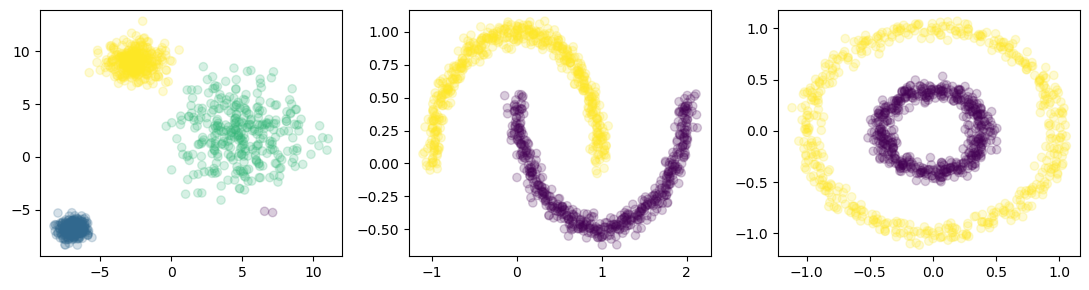

In [33]:
clusteringblb = DBSCAN(eps=1.5, min_samples=3).fit(blobs_data)
clusteringmoons = DBSCAN(eps=0.2, min_samples=3).fit(moons_data)
clusteringcircle = DBSCAN(eps=0.2, min_samples=3).fit(circles_data)
fig, ax = plt.subplots(1, 3, figsize=(11, 3))
ax[0].scatter(blobs_data[:,0], blobs_data[:,1], c=clusteringblb.labels_, alpha=.2)
ax[1].scatter(moons_data[:,0], moons_data[:,1], c=clusteringmoons.labels_, alpha=.2)
ax[2].scatter(circles_data[:,0], circles_data[:,1], c=clusteringcircle.labels_, alpha=.2)
plt.tight_layout()

<div class="alert alert-block alert-info">
<strong>Implementació:</strong> aplica Mean-shift als tres datasets anteriors i visualitza el seu resultat.
</div>

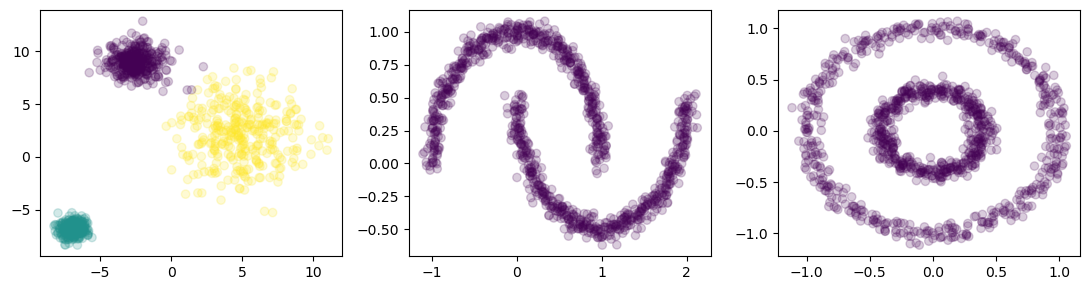

In [34]:
clusteringblb = MeanShift().fit(blobs_data)
clusteringmoons = MeanShift().fit(moons_data)
clusteringcircle = MeanShift().fit(circles_data)
fig, ax = plt.subplots(1, 3, figsize=(11, 3))
ax[0].scatter(blobs_data[:,0], blobs_data[:,1], c=clusteringblb.labels_, alpha=.2)
ax[1].scatter(moons_data[:,0], moons_data[:,1], c=clusteringmoons.labels_, alpha=.2)
ax[2].scatter(circles_data[:,0], circles_data[:,1], c=clusteringcircle.labels_, alpha=.2)
plt.tight_layout()

<div class="alert alert-block alert-info">
<strong>Anàlisi:</strong> En quins casos no s'ha pogut ajustar el resultat del model als clusters originals? Per què?
</div>

K-means funciona separant els grups a partir de centroides i els grups es decideixen a partir de la distància als centroides, els centroides és can movent segons la variància, veiem que aquest mètode funciona bé pel primer cas en què tenim tres clústers diferenciats cada un a un lloc de l'espai, però funciona malament en els altres dos, inclús dient-li el nombre de classes a identificar, cosa que és obligatòria al mètode. El primer ho fa bé, ja que si calculem el centroide dels punts de cada classe és a la distància mínima dels de la seva pròpia classe, en canvi, en el segon el centroide de cada una classe cau a punts de l'altra classe i en l'últim les dues classes comparteixen centroide.  Per tant, és impossible que pugui diferenciar les classes, ja que no pot trobar un centroide d'una classe sense contenir punt d'una altra classe.

Aglomerative funciona amb una estergia bottom up on cada observació és un clúster i les va unint progressivament, té diferents funcions per determinar com adjunta els grups, de base està "ward" que té un comportament molt similar a K-mens, ja que també busca minimitzar la variància per això he ulititzat aquest mètode pel primer, però pels següents he utilitzat "single" que el que busca és minimitzar la distància individual els elements més propers entre dos clústers, clarament aquest mètode funciona molt bé pels dos següents, ja que les observacions d'un mateix grup tenen una del seu propi grup més a prop que una de l'altre grup. 

DBSCAN funciona buscant zones de molta densitat de dades que seran clústers separats en zones de baixa densitat, com en els tres exemples tenim una distància entre les classes, per tant, li serà fàcil separar-les perquè la densitat de punts baixa molt o directament hi ha espais en blanc entre dues classes.

Mean-shift també calcula centroides, però ho fa a través de calcular la mitjana dels punts els quals tenim  i tendint el centroide cap allà, com el primer mètode a tenir un centroide i calcular els punts al voltant del centroide veiem un comportament molt similar al primer.



Ara que has experimentat amb diversos algorismes de clustering i has comprès els seus avantatges i desavantatges, és moment de prendre una decisió important:

<div class="alert alert-block alert-info">
<strong>Anàlisi:</strong> Quin algorisme de clustering seleccionaràs per agrupar el conjunt de dades de reviews? Per què?
</div>

Seleccionaré  AgglomerativeClustering(n_clusters=2,linkage="ward") perquè crec que tenim dues classes identificables possibles, la dels més positius i la dels més negatius i crec que no podem utilitzar un que busqui densitat o distància, ja que en tenir opinions intermèdies tindrem un gradient d'opinions i no clústers separats, per tant, no podem utilitzar dbscan o aglomerative amb single, ja que no podrà separar cap grup. Perquè he decidit utilitzar agglomerative i no K-mens o means shift? k-means i ward funcionen molt similar, però k-means has d'introduir-lo moltes vegades per la inicialització aleatòria dels centroides i les possibles valls locals on ens podem quedar. Per tant, he preferit ward a K-means. I entre ward i means shift mean shift és més lenta, també perquè funcioni bé la densitat de les mostres ha de ser suau i això es una cosa que no puc assegurar. Per tant, em quedaré amb AgglomerativeClustering(n_clusters=2,linkage="ward")

**Aplica'l al conjunt de dades de reviews**. Si trobes problemes de rendiment a causa de la mida del conjunt de dades original, pots reduir el problema utilitzant un conjunt de punts en 3D en lloc de la dada original perquè el càlcul sigui més ràpid i eficient.

<div class="alert alert-block alert-info">
<strong>Implementació:</strong> aplica l'algorisme de clustering seleccionat al conjunt de dades de reviews i visualitza el seu resultat. Modifica els paràmetres de l'algorisme perquè s'adapti a la dada.
</div>

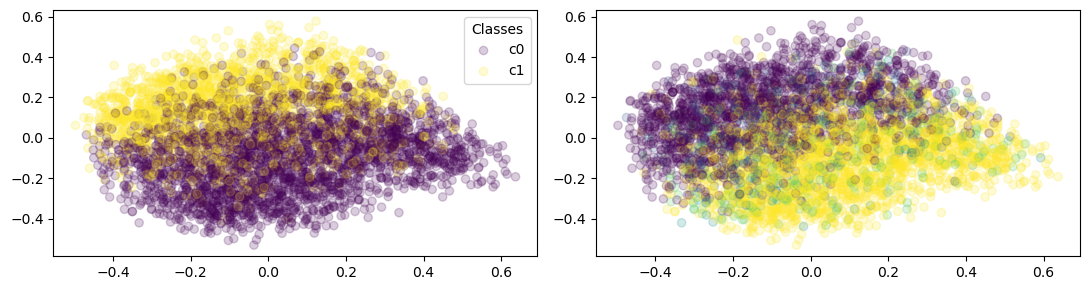

In [39]:
clustering =AgglomerativeClustering(n_clusters=2,linkage="ward").fit(embeddings)
fig, ax = plt.subplots(1, 2, figsize=(11, 3))
scatter=ax[0].scatter(pca_features[:,0], pca_features[:,1], c=clustering.labels_, alpha=.2)
handles, labels = scatter.legend_elements()
legend = ax[0].legend(handles = handles, labels = ["c0","c1" ], title="Classes")
ax[1].scatter(pca_features[:,0], pca_features[:,1], c=ratings, alpha=.2)

plt.tight_layout()

## Anàlisi dels clusters (3 punts)

Ara que has realitzat el clustering, és moment d'analitzar els resultats obtinguts per poder proporcionar insights al negoci.

<div class="alert alert-block alert-info">
<strong>Implementació:</strong> revisa la composició dels clusters. <strong>Per a cada cluster</strong> identificat, has de mostrar de manera clara i organitzada la informació següent:
<ul>
<li><strong>Nombre de reviews</strong> assignades a aquest cluster.
<li><strong>Mitjana d'estrelles</strong> de les reviews dins d'aquest cluster.
<li><strong>Reviews representatives:</strong> selecciona 5 reviews per a cada cluster que permetin tenir una idea general del seu contingut. Si el mètode de clustering utilitzat calcula els centroides (és a dir, el "centre" del cluster), selecciona les 5 reviews més properes al centre per a una representació més precisa.
Si el mètode no calcula centroides, simplement selecciona qualsevol 5 reviews del cluster.
</ul>
</div>

In [41]:
df=pd.DataFrame(data)
df["group"]=clustering.labels_
df.groupby("stars").count()    
    

,text,group
stars,,
1,1687,1687
2,228,228
3,156,156
4,329,329
5,2085,2085


In [46]:
groups=df["group"].unique()
for i in groups:
    print(df[df["group"]==i].groupby("stars").count())

       text  group
stars             
1      1069   1069
2       123    123
3        51     51
4        85     85
5       437    437
       text  group
stars             
1       618    618
2       105    105
3       105    105
4       244    244
5      1648   1648


In [42]:
df.groupby("group").count()

,text,stars
group,,
0,2720,2720
1,1765,1765


In [43]:
df.groupby("group").mean("stars")

,stars
group,
0,3.808456
1,2.262323


In [45]:
groups=df["group"].unique()
for i in groups:
    print(df[df["group"]==i].sample(5).to_string(index=False))

L'últim pas és la interpretació dels clusters mitjançant l'anàlisi de les mostres pertanyents a cada cluster.

<div class="alert alert-block alert-info">
<strong>Anàlisi:</strong> Pots identificar diferents temes o patrons en els missatges de cada cluster? Comenta la temàtica de cada cluster.
</div>

El primer clúster és el negatiu tenim 4 reviews molt dolentes (no passa del 2) i una de 5 estrelles, semblaria estrany que estiguis aquí, però el que diu és que una cosa se li va trencar i ells li van arreglar, però que una cosa es trenqui tendeix a ser una cosa negativa, per tant, ha entès que hi havia una cosa negativa, però no ha entès que ells l'han arreglat. Totes les altres utilitzen llenguatge negatiu amb l'experiència de la tenda, utilitzat paraules com "scam", "unpleasant", "mistake" 

L'altre grup són les positives i utilitza paraules positives com "helpful" "friendly" o "eficient" 

Sembla que hi ha paraules que estan en els dos grups com, "regular customer" que està als dos grups, per tant, això fa que certs valors a embedigs siguin iguals als dos grups, mentre que altres siguin diferents.


Com podem veure a la distribució de reviews per grups, en els dos grups les dues poblacions més abundants són 5 estrelles o 1 estrella, això té sentit perquè també són la majoria de les reviews. La mala classificació d'algunes pot ser com en l'exemple que veiem a dalt, on s'utilitza una paraula negativa com "broke" per descriure una situació positiva. I a l'inrevés sagú que també passa